# Homework 1: Implied Volatility for EUA Options

Background. You work on a bank’s EU Emissions (CO2) derivatives desk. The desk quotes implied volatility (IV) for European-style options written on EUA futures. The desk needs IV to compare strikes.

Data:
- Valuation date: 23 Jan 2026
- Underlying: EUA Dec-26 futures (quoted in EUR per EUA/tonne CO2)
- Futures last/settlement price: F0 = 88.44 EUR
- Option expiry: 15 Dec 2026 (European exercise)
- Discounting: use a flat continuously-compounded annual rate r = 1.933% (approx. STR around this date).
- Contract size (for PnL interpretation): 1 contract = 1,000 EUAs.

A 1 EUR move in the futures price changes the futures PnL by 1,000 EUR per contract

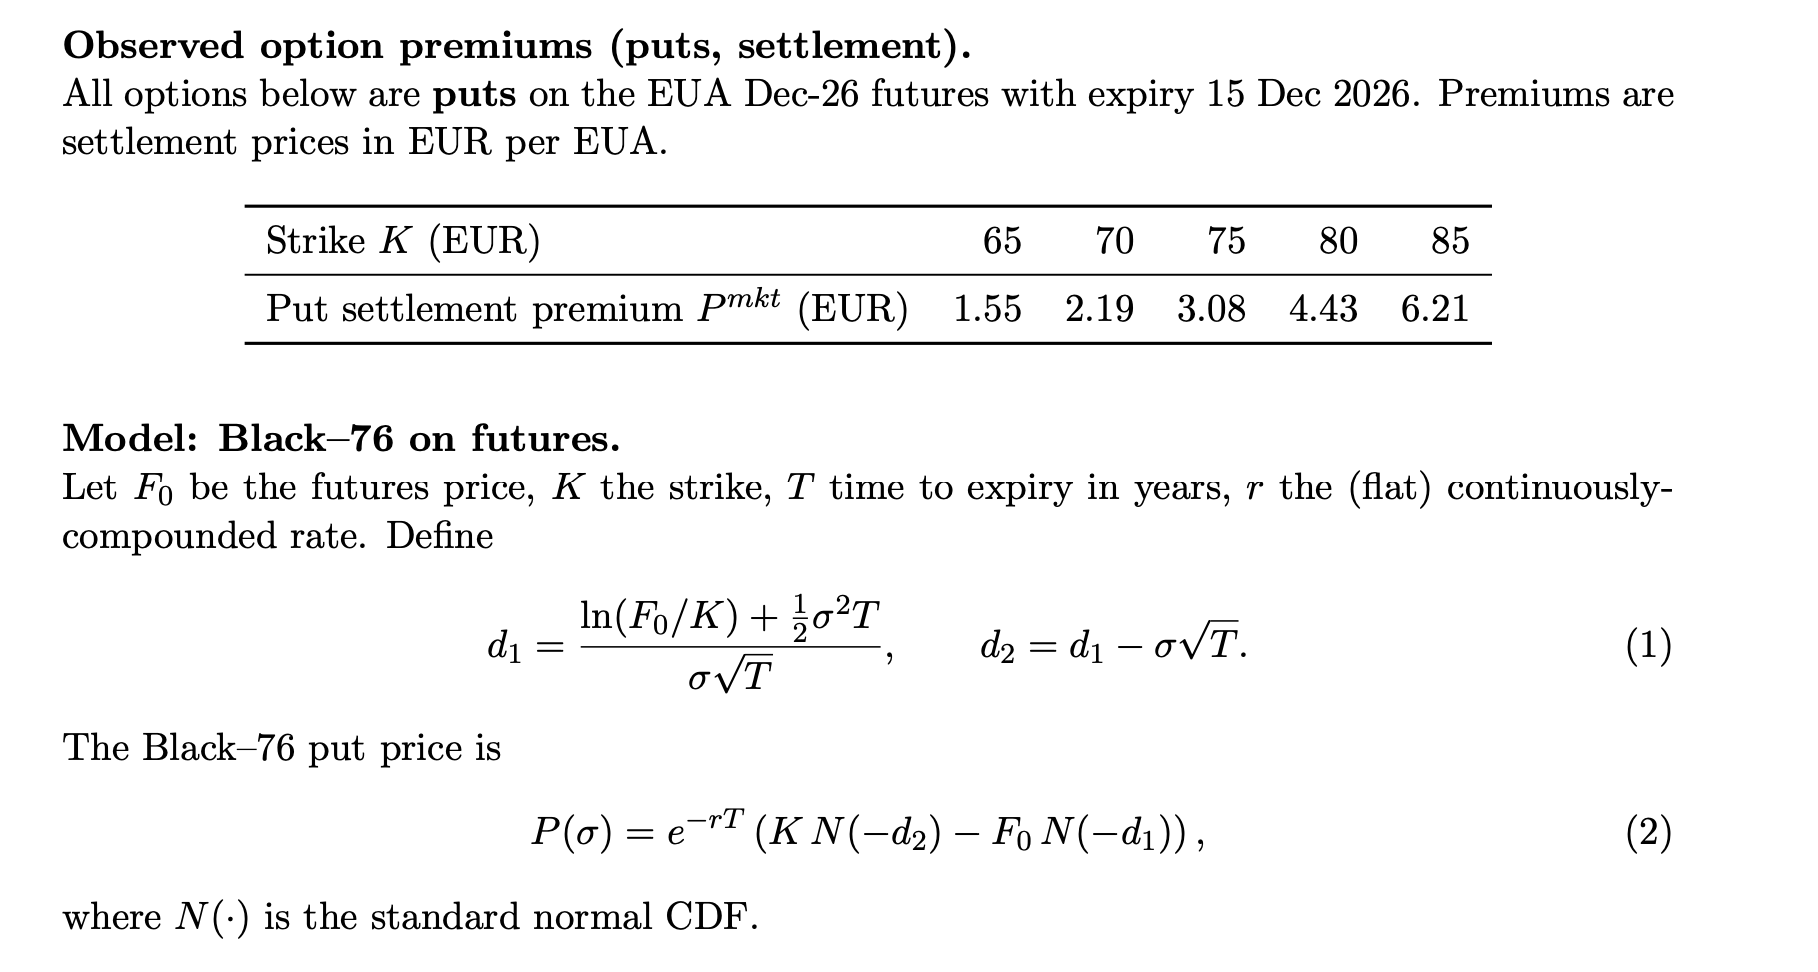

## Set up

In [ ]:
using Dates

In [21]:
#Parameters 1
valuation_date = Date(2026, 01, 23)
expiration_date = Date(2026, 12, 15)


settlement_price = 88.44
discount_rate = 0.01933
contract_size = 1000

1000

In [9]:
#Parameters 2

strike_levels = [65.0, 70.0, 75.0, 80.0, 85.0]      #strike levels
psm = [1.55, 2.19, 3.08, 4.43, 6.21]                #put settlement premium



[65.0, 70.0, 75.0, 80.0, 85.0][1.55, 2.19, 3.08, 4.43, 6.21]

## Task 1


In [ ]:
import Pkg; Pkg.add("DayCounts")

In [37]:
#Computing T

using Dates, DayCounts


valuation_date = Date(2026, 01, 23)
expiration_date = Date(2026, 12, 15)
dc = DayCounts.Actual365Fixed()

T = yearfrac(valuation_date, expiration_date, dc)

print("Years (T) to maturity:   ", T)

Years (T) to maturity:   0.8931506849315068

In [42]:
#Computig discount factor


discount_rate = 0.01933

discount_factor = exp(-discount_rate*T)
print("Discount factor is: ",discount_factor)


Discount factor is: 0.9828835765365862

In [43]:
import Pkg; Pkg.add("Distributions")
using Distributions

   Resolving package versions...
    Updating `~/.julia/environments/v1.12/Project.toml`
  [31c24e10] + Distributions v0.25.123
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [ ]:
psm = [1.55, 2.19, 3.08, 4.43, 6.21] 


In [92]:
#black-scholes iteratino function for vector of strike prices


settlement_price = 88.44
strike_levels = [65.0, 70.0, 75.0, 80.0, 85.0]      #strike levels


std_normal = Normal(0,1)

function black_scholes(σ)

    all_p = [] #storing put prices

    for i in 1:length(strike_levels)
        d1 = (log(settlement_price/strike_levels[i]) + 0.5*σ*T)/(σ*sqrt(T))
        d2 = d1 - σ*sqrt(T)

        P = discount_factor * (strike_levels[i] * cdf(std_normal,-d2) - settlement_price * cdf(std_normal, -d1))


        println("i: ", i, " "," strike: ", strike_levels[i], "  ","put: ", P)

        push!(all_p, P)

    end
    return all_p

end

black_scholes()

i: 1  strike: 65.0  put: 38.20922924120933
i: 2  strike: 70.0  put: 42.65100752678281
i: 3  strike: 75.0  put: 47.12191466703077
i: 4  strike: 80.0  put: 51.61846932609364
i: 5  strike: 85.0  put: 56.137788668169485


5-element Vector{Any}:
 38.20922924120933
 42.65100752678281
 47.12191466703077
 51.61846932609364
 56.137788668169485

In [93]:
#Import and downlaod packages

import Pkg; Pkg.add("Plots")
using Plots

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [134]:

settlement_price = 88.44                                #settlement price F_0
strike_levels = [65.0, 70.0, 75.0, 80.0, 85.0]          #strike levels
std_normal = Normal(0,1)                                #standard normal


function black_scholes2(σ,K)

        d1 = (log(settlement_price/K) + 0.5*σ*T)/(σ*sqrt(T))
        d2 = d1 - σ*sqrt(T)

        P = discount_factor * (K * cdf(std_normal,-d2) - settlement_price * cdf(std_normal, -d1))
        return P
end


black_scholes2 (generic function with 1 method)

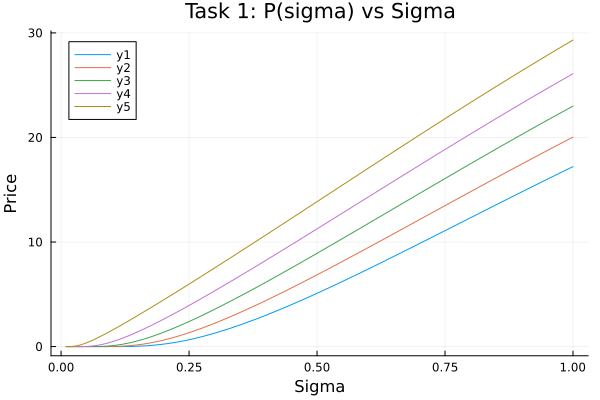

In [177]:
# sigma, strike (K)

strike_levels = [65.0, 70.0, 75.0, 80.0, 85.0]   
sigma_levels = 0.01:0.01:1

plt = plot(title="Task 1: P(sigma) vs Sigma", xlabel="Sigma", ylabel="Price")

for b in strike_levels

    price_put=[]

    for g in sigma_levels
        pag = black_scholes2(g, b)
        push!(price_put, pag)
    end

    plot!(plt, sigma_levels, price_put)

end

display(plt)




## Task 2: Implied volatility via root finding

5-element Vector{Any}:
 3.378539425746525e-12
 7.700893834499322e-8
 0.00010557936637308537
 0.015137753208200648
 0.3663933175314508

In [158]:
settlement_price = 88.44                                #settlement price F_0

strike_levels = [65.0, 70.0, 75.0, 80.0, 85.0]          #strike levels
market_premiums = [1.55, 2.19, 3.08, 4.43, 6.21]


function black_scholes2(σ,K)

        d1 = (log(settlement_price/K) + 0.5*σ*T)/(σ*sqrt(T))
        d2 = d1 - σ*sqrt(T)

        P = discount_factor * (K * cdf(std_normal,-d2) - settlement_price * cdf(std_normal, -d1))
        return P
end


black_scholes2 (generic function with 1 method)

## Bisection Algorithm for Root Finding

In [169]:
function bisection2(f, a, b)

    tol = 1e-1
    
    for i in 1:100

        x = (a+b) / 2
        error1 = (b-a)/2

        println("i: ",i,"       ", "x:  ", round(x, digits = 5),"        ", "ϵ: ", round(error1, digits = 5))

        if f(a) * f(b) > 0 
            print("Root not in interval")
            return nothing
        end


        if abs(x - a) <= tol
            print("The root is:     ")
            return round(x, digits = 5)


        elseif f(a) * f(x) < 0
            b = x
        else 
            a = x
        end

    
    end

    return x
end

    

bisection2 (generic function with 2 methods)

In [ ]:

implied_vols = []

println("Strike | Implied Vol | Iterations")
println("---------------------------------")


for i in 1:length(strike_levels)

    K = strike_levels[i]
    target_P = market_premiums[i]

    f(σ) = black_scholes2(σ, K) - target_P

    sigma_hat, iters = bisection2(f, 1e-6, 5.0)

    push!(implied_vols, sigma_hat)
    println("$K   | $(round(sigma_hat, digits=4))      | $iters")

end




Strike | Implied Vol | Iterations
---------------------------------
i: 1       x:  2.5        ϵ: 2.5
i: 2       x:  1.25        ϵ: 1.25
i: 3       x:  0.625        ϵ: 0.625
i: 4       x:  0.3125        ϵ: 0.3125
i: 5       x:  0.46875        ϵ: 0.15625
i: 6       x:  0.39063        ϵ: 0.07812
The root is:     

BoundsError: BoundsError: attempt to access Float64 at index [2]

## Task 3: Volatility Smile

ErrorException: Cannot convert Normal{Float64} to series data for plotting